In [2]:
from utils import ASSETS_DIR
import torch
import torch.nn.functional as F
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import torch.nn as nn
from utils.models import load_all_skops
import torch.optim as optim
from sklearn.utils import resample
from utils.dataset import undersample_dataset
import models.quantum.quantum_machine_learning as qml
from qiskit.circuit.library import real_amplitudes

La root del progetto è: /home/kirjia/ProgettoQuantumBioetria/src


In [3]:
params = {
           'reps': 2,
             'ansatz_fun': real_amplitudes,
               'entanglement': 'reverse_linear'
               }
dimension_padded, num_blocks, pad_size = qml.zero_padding(6, 32)

final_data = qml.build_quantum_circuit(real_qubits=6,
                                        encoding_depth=num_blocks,
                                          **params)
final_circuit = final_data['quantum_circuit']
weight_params = final_data['weight_params']
input_params = final_data['input_params']
final_circuit.draw('mpl')
print(final_data['weight_params'])

Costruzione del layer 0 con 6 qubits reali e 36 qubits totali
Costruzione del layer 1 con 6 qubits reali e 36 qubits totali
Costruzione del layer 2 con 6 qubits reali e 36 qubits totali
Costruzione del layer 3 con 6 qubits reali e 36 qubits totali
Costruzione del layer 4 con 6 qubits reali e 36 qubits totali
Costruzione del layer 5 con 6 qubits reali e 36 qubits totali
[ParameterVectorElement(θ_0[0]), ParameterVectorElement(θ_0[1]), ParameterVectorElement(θ_0[2]), ParameterVectorElement(θ_0[3]), ParameterVectorElement(θ_0[4]), ParameterVectorElement(θ_0[5]), ParameterVectorElement(θ_0[6]), ParameterVectorElement(θ_0[7]), ParameterVectorElement(θ_0[8]), ParameterVectorElement(θ_0[9]), ParameterVectorElement(θ_0[10]), ParameterVectorElement(θ_0[11]), ParameterVectorElement(θ_0[12]), ParameterVectorElement(θ_0[13]), ParameterVectorElement(θ_0[14]), ParameterVectorElement(θ_0[15]), ParameterVectorElement(θ_0[16]), ParameterVectorElement(θ_0[17]), ParameterVectorElement(θ_1[0]), ParameterVe

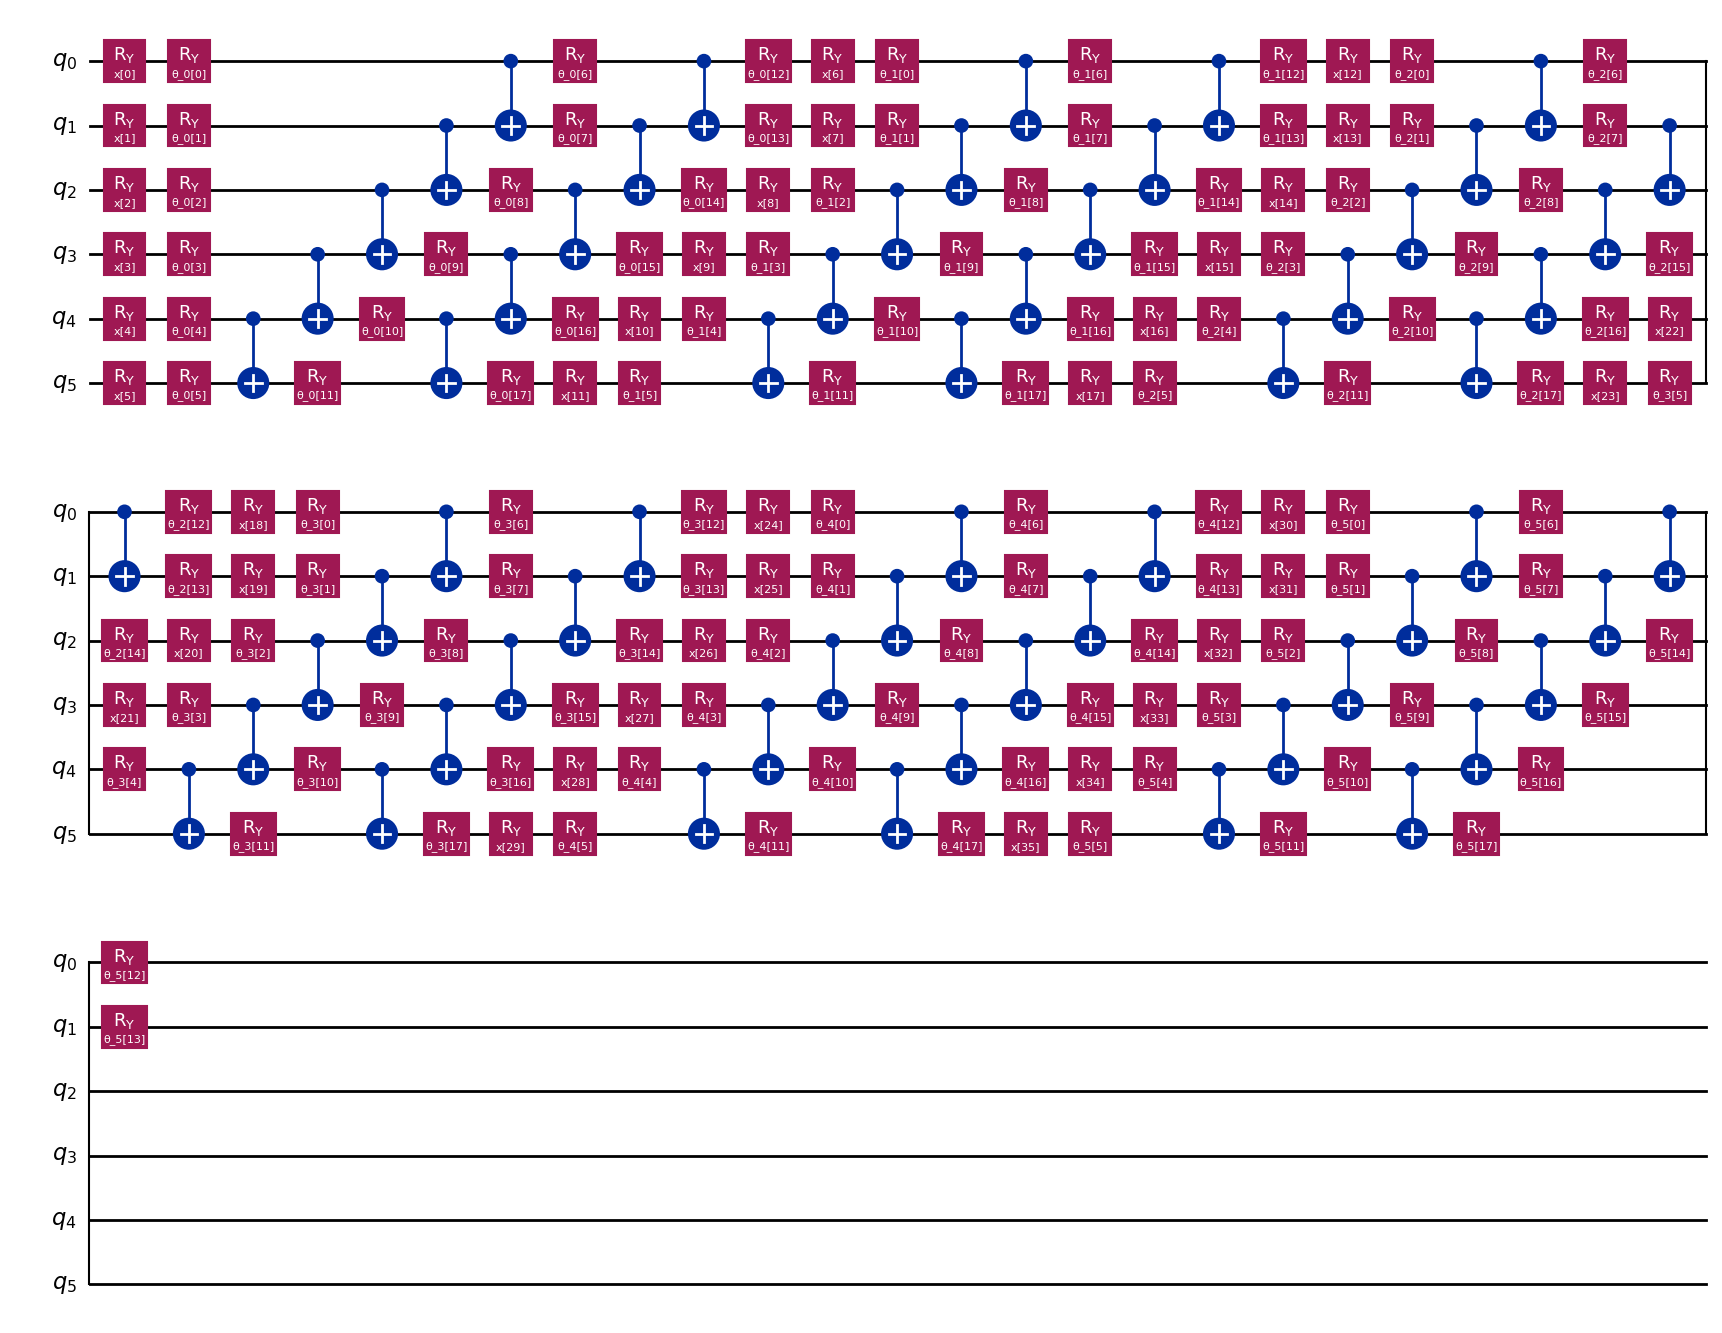

In [4]:
final_circuit.draw('mpl')

In [ ]:
num_qubits = 6
dim = [4, 8, 16, 32]


objs = load_all_skops(ASSETS_DIR / "seeds_11") 
objs.pop('scaler')
pca32 = objs['pca_32']

dataset = pd.read_csv(ASSETS_DIR / "seeds_11/train_11.csv")
dataset = undersample_dataset(dataset, label_col='label', random_seed=11)
dataset = resample(dataset, replace=False, n_samples=4000, stratify=dataset["label"], random_state=11)
val = pd.read_csv(ASSETS_DIR / "seeds_11/val_11.csv")
val = undersample_dataset(val, label_col='label', random_seed=11)
X_train = dataset.drop(columns=["label"])

#PCA su train
X_train = pca32.transform(X_train.values)
Y_train = dataset["label"]

#PCA su val
X_val = val.drop(columns=["label"])
X_val = pca32.transform(X_val.values)
Y_val = val["label"]

del dataset

scaler = MinMaxScaler(feature_range=(0, np.pi))
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

tensor = torch.from_numpy(X_train).float()
tensor.size()
tensor_Y = torch.from_numpy(Y_train.values).long()

tensor_val = torch.from_numpy(X_val).float()
tensor_Y_val = torch.from_numpy(Y_val.values).long()



Caricamento di: scaler.skops...
scaler caricato con successo.
Caricamento di: pca_16.skops...
pca_16 caricato con successo.
Caricamento di: pca_4.skops...
pca_4 caricato con successo.
Caricamento di: pca_32.skops...
pca_32 caricato con successo.
Caricamento di: pca_8.skops...
pca_8 caricato con successo.
Dimensione classe minoritaria trovata: 7093 elementi.
Dimensione classe minoritaria trovata: 886 elementi.


/tmp/ipykernel_21146/764111631.py:29: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  tensor_Y = torch.from_numpy(Y_train.values).long()


In [6]:


X_padded = F.pad(tensor, (0, dimension_padded - dim[3]), mode="constant", value=0.0)


dataset_train = torch.utils.data.TensorDataset(
    X_padded.float(),
    torch.from_numpy(Y_train.values).long()
)
print(f"Dataset train size: {dataset_train.__len__()} samples")
dataloader_train = torch.utils.data.DataLoader(dataset_train, batch_size=128, shuffle=True, num_workers=12, pin_memory=True)

X_padded_val = F.pad(tensor_val, (0, dimension_padded - dim[3]), mode="constant", value=0.0)
dataset_val = torch.utils.data.TensorDataset(
    X_padded_val.float(),
    torch.from_numpy(Y_val.values).long()
)
print(f"Dataset val size: {dataset_val.__len__()} samples")
dataloader_val = torch.utils.data.DataLoader(dataset_val, batch_size=128, shuffle=True, num_workers=12, pin_memory=True)




Dataset train size: 4000 samples
Dataset val size: 3544 samples


In [7]:

#observables = qml.pauli_observable(num_qubits, "ZXY")
observables = qml.pauli_observable(num_qubits, "Z")
print(observables)

quantum_model = qml.VQC(num_qubits, 
                        quantum_circuit=final_circuit,
                        obs=observables,
                        weight_params=weight_params,
                        input_params=input_params,
                        target_classes=4)
quantum_model.to("cuda")

[SparsePauliOp(['IIIIIZ'],
              coeffs=[1.+0.j]), SparsePauliOp(['IIIIZI'],
              coeffs=[1.+0.j]), SparsePauliOp(['IIIZII'],
              coeffs=[1.+0.j]), SparsePauliOp(['IIZIII'],
              coeffs=[1.+0.j]), SparsePauliOp(['IZIIII'],
              coeffs=[1.+0.j]), SparsePauliOp(['ZIIIII'],
              coeffs=[1.+0.j])]


/home/kirjia/venv-pytorch/lib/python3.12/site-packages/qiskit_machine_learning/connectors/torch_connector.py:378: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self._weights.data = torch.tensor(initial_weights, dtype=torch.float)


VQC(
  (quantum_layer): TorchConnector()
  (head_classical_linear_layer): Linear(in_features=6, out_features=4, bias=True)
)

In [8]:
'''from torch.nn.utils import parameters_to_vector, vector_to_parameters

criterion = nn.CrossEntropyLoss()

def objective_function(weights_np):
    # Trasforma i numeri di Qiskit in tensori di PyTorch
    weights_tensor = torch.tensor(weights_np, dtype=torch.float32)
    vector_to_parameters(weights_tensor, [quantum_model.q_weights])
    
    # Prendi un batch dal tuo dataloader di PyTorch
    batch_X, batch_y = next(iter(dataloader_train))
    
    # Calcola l'errore
    with torch.no_grad():
        logits = quantum_model(batch_X)
        loss = criterion(logits, batch_y)
        
    return loss.item()'''

"from torch.nn.utils import parameters_to_vector, vector_to_parameters\n\ncriterion = nn.CrossEntropyLoss()\n\ndef objective_function(weights_np):\n    # Trasforma i numeri di Qiskit in tensori di PyTorch\n    weights_tensor = torch.tensor(weights_np, dtype=torch.float32)\n    vector_to_parameters(weights_tensor, [quantum_model.q_weights])\n\n    # Prendi un batch dal tuo dataloader di PyTorch\n    batch_X, batch_y = next(iter(dataloader_train))\n\n    # Calcola l'errore\n    with torch.no_grad():\n        logits = quantum_model(batch_X)\n        loss = criterion(logits, batch_y)\n\n    return loss.item()"

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(quantum_model.parameters(), lr=0.01)
epochs = 20
patience = 7
best_val_loss = float('inf')

QNN

In [ ]:
import time


for epoch in range(epochs):
    quantum_model.train()
    running_loss = 0.0
    start_time = time.time()
    
    # Il dataloader_train fornisce iterativamente i batch (es. da 32)
    for batch_X, batch_y in dataloader_train:
        '''print(f"Batch size: {batch_X[0].shape}")
        print(f"Unique labels in batch: {batch_y.unique()}")
        print(f"Max label: {batch_y.max()}, Min label: {batch_y.min()}")'''

        batch_X = batch_X.to("cuda", non_blocking=True)
        batch_y = batch_y.to("cuda", non_blocking=True)
        
        # A. Azzeriamo i gradienti
        optimizer.zero_grad()
        
        # B. FORWARD PASS
        # Qui la QNN crea in automatico il PUB per l'intero batch e lo esegue
        logits = quantum_model(batch_X)

        '''print(f"Shape di logits: {logits.shape}")
        print(f"Shape di batch_y: {batch_y.shape}")
        print(f"Tipo di batch_y: {batch_y.dtype}")'''
        
        # C. Calcolo della Loss
        loss = criterion(logits, batch_y)
        
        
        loss.backward()
        
        # E. Aggiornamento dei pesi
        optimizer.step()
        
        running_loss += loss.item()
        print("#", end="")
    print()  # Per andare a capo dopo la barra di avanzamento
    step_time = time.time() - start_time
        
    print(f"Tempo per epoca {epoch+1}: {step_time:.2f} secondi")
    
    loss_media = running_loss / len(dataloader_train)
    print(f"Epoca {epoch+1}/{epochs} - Loss: {loss_media:.4f}")

################################
Tempo per epoca 1: 263.47 secondi
Epoca 1/20 - Loss: 1.4653
################################
Tempo per epoca 2: 262.43 secondi
Epoca 2/20 - Loss: 1.4385
################################
Tempo per epoca 3: 256.93 secondi
Epoca 3/20 - Loss: 1.4162
################################
Tempo per epoca 4: 249.73 secondi
Epoca 4/20 - Loss: 1.4033
########################

In [ ]:
import qiskit
qiskit.__version__